<h2>Apri questo notebook in Google Colab</h2>

<div align="left" style="margin: 20px 0;">
  <a href="https://colab.research.google.com/github/LeonardoCofone/The-AI-Handbook/blob/main/chapter_8_Machine_Learning.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
  </a>
</div>

# Capitolo 8, Regolarizzazione

In questo notebook vediamo come domare l'overfitting con la regolarizzazione: Ridge, Lasso, Elastic Net ed early stopping.  
Partiamo da un modello che overfitta di proposito e lo curiamo passo dopo passo. Cambia gli alpha, rompi le cose, guarda come reagiscono i pesi.

## 0. Setup, importare le librerie

In [1]:
%pip install numpy matplotlib scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import root_mean_squared_error

np.random.seed(42)
print('Setup completato!')

Setup completato!


## 1. Un dataset con feature utili e feature inutili

Costruiamo un problema dove solo 3 feature su 10 contano davvero (le altre 7 sono rumore puro).  
Cosi potremo vedere con i nostri occhi chi, tra Ridge e Lasso, riesce a smascherare le feature inutili.

In [3]:
m = 50
X = np.random.randn(m, 10)
# Solo le prime 3 feature hanno un peso reale, le altre 7 valgono 0
true_coef = np.array([5, -4, 3, 0, 0, 0, 0, 0, 0, 0])
y = X @ true_coef + np.random.randn(m) * 0.5

print('Pesi veri:', true_coef)

Pesi veri: [ 5 -4  3  0  0  0  0  0  0  0]


## 2. Ridge: riduce i pesi ma non li azzera

Alleniamo Ridge e guardiamo i pesi che impara. Nota come tutte le feature mantengano un peso diverso da zero, anche quelle inutili: Ridge le smorza ma non le elimina.

In [4]:
ridge = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
ridge.fit(X, y)
pesi_ridge = ridge.named_steps["ridge"].coef_

print('Pesi Ridge (arrotondati):')
print(pesi_ridge.round(2))
print(f'Pesi esattamente a zero: {(pesi_ridge == 0).sum()} su 10')

Pesi Ridge (arrotondati):
[ 4.45 -3.92  3.26 -0.01  0.06 -0.02 -0.01  0.1  -0.1  -0.1 ]
Pesi esattamente a zero: 0 su 10


## 3. Lasso: azzera le feature inutili

Stesso dataset, stesso codice, ma con Lasso. Guarda quanti pesi finiscono esattamente a zero: sono le feature che Lasso ha deciso di buttare via. Questa e la feature selection automatica.

In [5]:
lasso = make_pipeline(StandardScaler(), Lasso(alpha=0.1))
lasso.fit(X, y)
pesi_lasso = lasso.named_steps["lasso"].coef_

print('Pesi Lasso (arrotondati):')
print(pesi_lasso.round(2))
print(f'Pesi esattamente a zero: {(pesi_lasso == 0).sum()} su 10')

Pesi Lasso (arrotondati):
[ 4.48 -3.85  3.22 -0.    0.    0.   -0.    0.   -0.   -0.  ]
Pesi esattamente a zero: 7 su 10


## 4. Il confronto visivo: i coefficient paths

Facciamo variare alpha su un ampio intervallo e disegniamo come si muovono i pesi.  
**Ridge**: i pesi scendono dolcemente ma restano tutti vivi. **Lasso**: i pesi inutili vengono azzerati uno a uno.

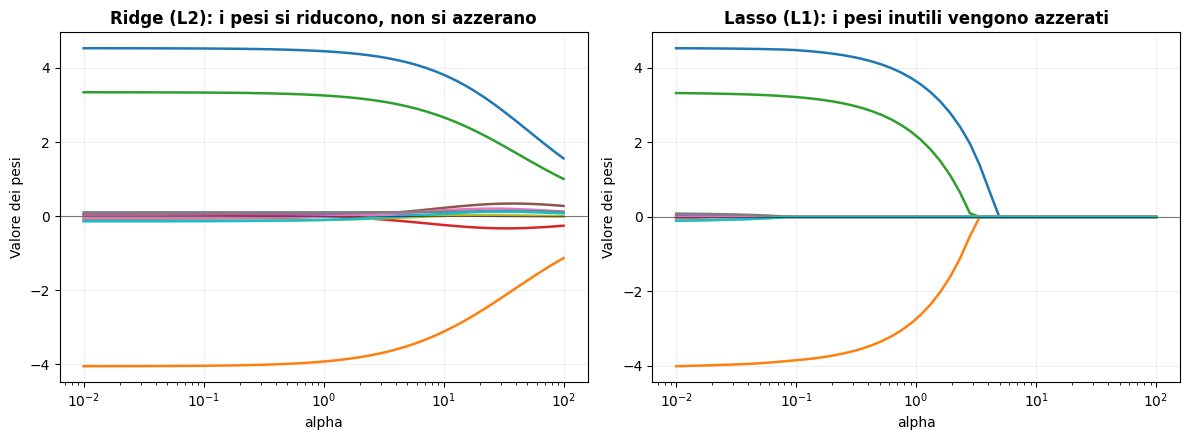

In [6]:
alphas = np.logspace(-2, 2, 50)
ridge_coefs, lasso_coefs = [], []
for a in alphas:
    r = make_pipeline(StandardScaler(), Ridge(alpha=a)).fit(X, y)
    l = make_pipeline(StandardScaler(), Lasso(alpha=a, max_iter=10000)).fit(X, y)
    ridge_coefs.append(r.named_steps["ridge"].coef_)
    lasso_coefs.append(l.named_steps["lasso"].coef_)
ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for i in range(10):
    axes[0].plot(alphas, ridge_coefs[:, i], linewidth=1.8)
    axes[1].plot(alphas, lasso_coefs[:, i], linewidth=1.8)
axes[0].set_xscale('log'); axes[1].set_xscale('log')
axes[0].set_title('Ridge (L2): i pesi si riducono, non si azzerano', fontweight='bold')
axes[1].set_title('Lasso (L1): i pesi inutili vengono azzerati', fontweight='bold')
for ax in axes:
    ax.set_xlabel('alpha'); ax.set_ylabel('Valore dei pesi')
    ax.axhline(0, color='black', linewidth=0.8, alpha=0.5); ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 5. Trovare il miglior alpha in automatico

Invece di provare gli alpha a mano, RidgeCV e LassoCV integrano la cross-validation e scelgono da soli il valore migliore.

In [7]:
ridge_cv = make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-2, 2, 20), cv=5))
ridge_cv.fit(X, y)

lasso_cv = make_pipeline(StandardScaler(), LassoCV(alphas=np.logspace(-2, 2, 20), cv=5, max_iter=10000))
lasso_cv.fit(X, y)

print(f'Miglior alpha Ridge: {ridge_cv.named_steps["ridgecv"].alpha_:.4f}')
print(f'Miglior alpha Lasso: {lasso_cv.named_steps["lassocv"].alpha_:.4f}')

Miglior alpha Ridge: 0.1833
Miglior alpha Lasso: 0.0428


## 6. Elastic Net: il mix tra i due

Elastic Net combina L1 e L2. Il parametro `l1_ratio` decide il dosaggio: 0 = Ridge pura, 1 = Lasso puro, 0.5 = meta e meta.  
Proviamo tre dosaggi diversi e confrontiamo quanti pesi azzerano.

In [8]:
for ratio in [0.1, 0.5, 0.9]:
    en = make_pipeline(StandardScaler(), ElasticNet(alpha=0.1, l1_ratio=ratio, max_iter=10000))
    en.fit(X, y)
    coef = en.named_steps["elasticnet"].coef_
    print(f'l1_ratio={ratio}: {(coef == 0).sum()} pesi azzerati su 10')

l1_ratio=0.1: 1 pesi azzerati su 10
l1_ratio=0.5: 2 pesi azzerati su 10
l1_ratio=0.9: 5 pesi azzerati su 10


## 7. Early Stopping: fermarsi al momento giusto

Un modo diverso di regolarizzare: non tocchiamo la funzione di costo, ma fermiamo il training quando il validation error smette di scendere.  
Usiamo un polinomio di grado altissimo (che overfitterebbe di sicuro) e lo alleniamo un'epoca alla volta con `partial_fit`.

In [9]:
from copy import deepcopy
from sklearn.linear_model import SGDRegressor

m = 100
X1 = 6 * np.random.rand(m, 1) - 3
y1 = 0.5 * X1**2 + X1 + 2 + np.random.randn(m, 1)

# Meta training, meta validation
X_train, y_train = X1[:m // 2], y1[:m // 2, 0]
X_valid, y_valid = X1[m // 2:], y1[m // 2:, 0]

preprocessing = make_pipeline(
    PolynomialFeatures(degree=90, include_bias=False),
    StandardScaler()
)
X_train_prep = preprocessing.fit_transform(X_train)
X_valid_prep = preprocessing.transform(X_valid)

sgd_reg = SGDRegressor(penalty=None, eta0=0.002, random_state=42)
n_epochs = 2000
best_valid_rmse = float("inf")
train_errors, val_errors = [], []

for epoch in range(n_epochs):
    sgd_reg.partial_fit(X_train_prep, y_train)   # una epoca alla volta
    train_errors.append(root_mean_squared_error(y_train, sgd_reg.predict(X_train_prep)))
    val_error = root_mean_squared_error(y_valid, sgd_reg.predict(X_valid_prep))
    val_errors.append(val_error)
    if val_error < best_valid_rmse:
        best_valid_rmse = val_error
        best_epoch = epoch
        best_model = deepcopy(sgd_reg)   # copia congelata del miglior modello

print(f'Miglior epoca: {best_epoch}, con validation RMSE = {best_valid_rmse:.3f}')

Miglior epoca: 712, con validation RMSE = 0.989


*Nota: `partial_fit` allena una epoca per volta, cosi possiamo misurare il validation error a ogni passo. E `deepcopy` è essenziale: senza, `best_model` sarebbe solo un riferimento a `sgd_reg` e verrebbe sovrascritto ogni epoca.*

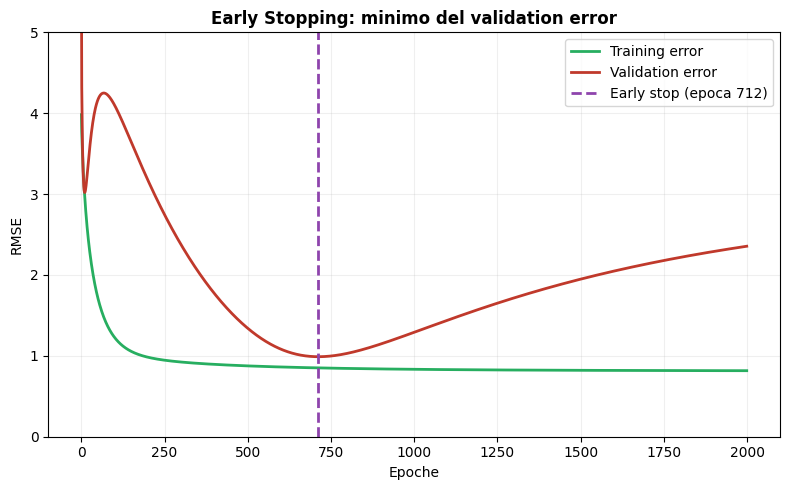

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(train_errors, color='#27AE60', linewidth=2, label='Training error')
plt.plot(val_errors, color='#C0392B', linewidth=2, label='Validation error')
plt.axvline(best_epoch, color='#8E44AD', linestyle='--', linewidth=2, label=f'Early stop (epoca {best_epoch})')
plt.xlabel('Epoche'); plt.ylabel('RMSE')
plt.title('Early Stopping: minimo del validation error', fontweight='bold')
plt.ylim(0, 5)
plt.legend(); plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

Abbiamo visto quattro modi di combattere l'overfitting. **Ridge** smorza tutti i pesi senza azzerarli. **Lasso** azzera le feature inutili facendo feature selection. **Elastic Net** mescola i due. **Early stopping** ferma il training al momento giusto.

Il filo comune: penalizzare la complessita per generalizzare meglio. E una logica che ritroverai nella regressione logistica, nelle SVM e nelle reti neurali.

Nel prossimo capitolo cambiamo prospettiva: invece di domare le feature, impariamo a costruirle bene. Si parla di **Feature Engineering!!!!**.